# LIBRERIAS

In [71]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy

# LECTURA DE DATOS

In [2]:
data_dir = Path("./Estaciones Aut - Precipitación")

data_files = list(data_dir.glob("*.data"))

print(f"Archivos encontrados: {len(data_files)}")

Archivos encontrados: 611


In [ ]:
def read_climate_data(file_path, chunksize=300_000):
    chunks = []

    for chunk in pd.read_csv(
        file_path,
        sep="|",
        parse_dates=["Fecha"],
        dtype={"Valor": "float32"},
        chunksize=chunksize
    ):
        # Metadatos desde el nombre del archivo
        chunk["station_id"] = file_path.stem.split("@")[-1]
        chunk["variable"] = file_path.stem.split("@")[0]

        chunks.append(chunk)

    return pd.concat(chunks, ignore_index=True)

In [4]:
dfs = []

for file in data_files:
    df = read_climate_data(file)
    dfs.append(df)

climate_df = pd.concat(dfs, ignore_index=True)

Leyendo PT_AUT_10@11017020.data
Leyendo PT_AUT_10@11027030.data
Leyendo PT_AUT_10@11030010.data
Leyendo PT_AUT_10@11035030.data
Leyendo PT_AUT_10@11037030.data
Leyendo PT_AUT_10@11045010.data
Leyendo PT_AUT_10@11047040.data
Leyendo PT_AUT_10@11050020.data
Leyendo PT_AUT_10@11057020.data
Leyendo PT_AUT_10@11077020.data
Leyendo PT_AUT_10@11080010.data
Leyendo PT_AUT_10@11105020.data
Leyendo PT_AUT_10@1111500036.data
Leyendo PT_AUT_10@11115020.data
Leyendo PT_AUT_10@11117040.data
Leyendo PT_AUT_10@11117050.data
Leyendo PT_AUT_10@11135030.data
Leyendo PT_AUT_10@11155030.data
Leyendo PT_AUT_10@1117500060.data
Leyendo PT_AUT_10@12015060.data
Leyendo PT_AUT_10@12015100.data
Leyendo PT_AUT_10@12015110.data
Leyendo PT_AUT_10@12017020.data
Leyendo PT_AUT_10@12025040.data
Leyendo PT_AUT_10@12027010.data
Leyendo PT_AUT_10@12045020.data
Leyendo PT_AUT_10@1206500136.data
Leyendo PT_AUT_10@13027040.data
Leyendo PT_AUT_10@1303500074.data
Leyendo PT_AUT_10@1303500129.data
Leyendo PT_AUT_10@13035501.dat

In [ ]:
print(climate_df.head())

                Fecha  Valor station_id   variable
0 2019-07-06 00:20:00    0.0   11017020  PT_AUT_10
1 2019-07-06 00:30:00    0.0   11017020  PT_AUT_10
2 2019-07-06 00:40:00    0.0   11017020  PT_AUT_10
3 2019-07-06 00:50:00    0.0   11017020  PT_AUT_10
4 2019-07-06 01:00:00    0.0   11017020  PT_AUT_10
Fecha         datetime64[us]
Valor                float32
station_id               str
variable                 str
dtype: object
Fecha         0
Valor         0
station_id    0
variable      0
dtype: int64


# PUNTO 1

In [6]:
# df ya leído desde parquet
df = climate_df.sort_values("Fecha").set_index("Fecha")

# Opcional: filtrar mínimo 10 años
df = df.loc["2010-01-01":]

In [7]:
print(df.index.min(), df.index.max())

2010-01-01 00:00:00 2023-04-07 08:00:00


In [11]:
aggregation_levels = {
    "15 min": "15min",
    "30 min": "30min",
    "1 h": "1h",
    "3 h": "3h",
    "6 h": "6h",
    "12 h": "12h",
    "24 h": "24h"
}

In [12]:
aggregated_series = {}

for label, rule in aggregation_levels.items():
    aggregated_series[label] = (
        df["Valor"]
        .resample(rule)
        .sum(min_count=1)
    )

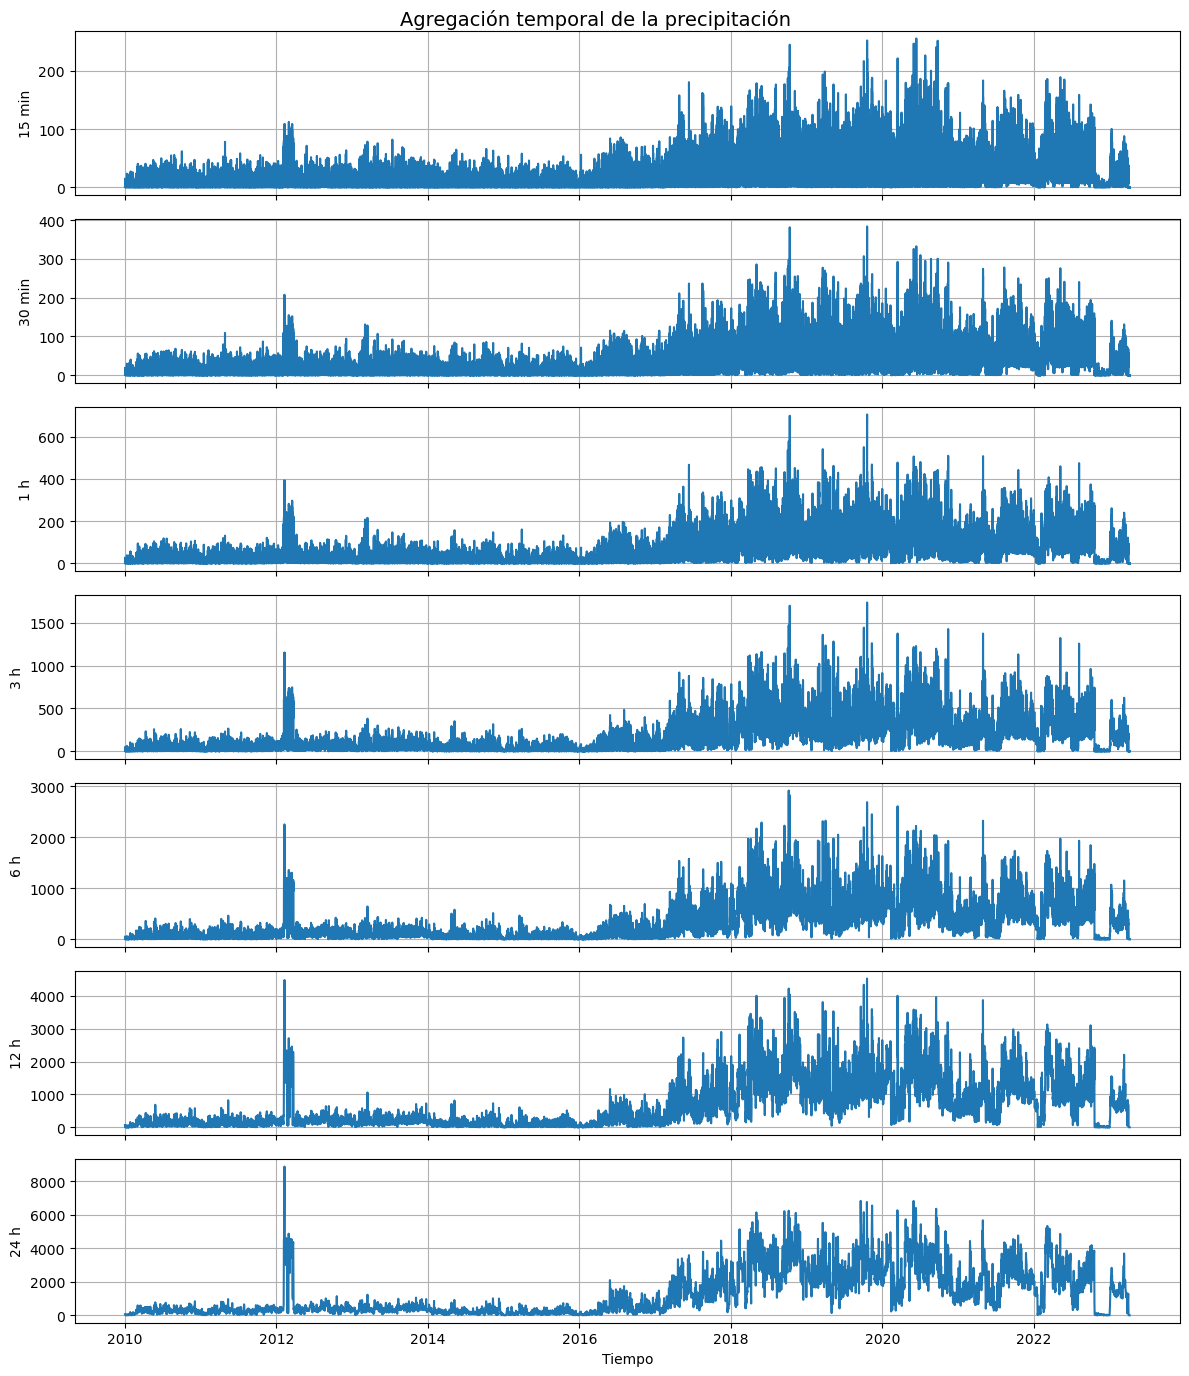

In [14]:
fig, axes = plt.subplots(
    nrows=7,
    ncols=1,
    figsize=(12, 14),
    sharex=True
)

for ax, (label, series) in zip(axes, aggregated_series.items()):
    ax.plot(series.index, series.values)
    ax.set_ylabel(label)
    ax.grid(True)

axes[-1].set_xlabel("Tiempo")

plt.suptitle("Agregación temporal de la precipitación", fontsize=14)
plt.tight_layout()
plt.show()

# PUNTO 2

In [37]:
# Remuestreo mensual
monthly_precip = df["Valor"].resample("ME").sum(min_count=1)

In [38]:
oni = pd.read_csv(
    "oni.ascii",
    sep=r"\s+",
    comment=';',
    engine="python"
)

oni_df = oni[["YR", "MON", "ANOM.3"]].copy()
oni_df.columns = ["Year", "Month", "ONI"]

In [57]:
columnas = [
    "Year", "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

mei = pd.read_csv(
    "mei.txt",
    sep=r"\s+",
    header=None,
    names=columnas,
    engine="python",
    on_bad_lines="skip"
)

mei = mei.dropna(subset=["Feb"])

In [45]:
monthly_precip = monthly_precip.copy()
monthly_precip.index = pd.to_datetime(monthly_precip.index)
monthly_precip = monthly_precip.asfreq("ME")
monthly_precip.name = "precip"

In [47]:
oni = oni_df.copy()

oni["date"] = pd.to_datetime(
    dict(year=oni["Year"], month=oni["Month"], day=1)
) + pd.offsets.MonthEnd(0)

oni = oni.set_index("date")["ONI"].asfreq("ME")

In [58]:
# Forzar Year a numérico; lo que no sea número se vuelve NaN
mei["Year"] = pd.to_numeric(mei["Year"], errors="coerce")

# Eliminar filas no numéricas (ej. encabezados incrustados)
mei = mei.dropna(subset=["Year"])

# Convertir Year a entero
mei["Year"] = mei["Year"].astype(int)

mei_long = mei.melt(
    id_vars="Year",
    var_name="Month",
    value_name="MEI"
)
month_map = {
    "Jan":1,"Feb":2,"Mar":3,"Apr":4,"May":5,"Jun":6,
    "Jul":7,"Aug":8,"Sep":9,"Oct":10,"Nov":11,"Dec":12
}

mei_long["Month"] = mei_long["Month"].map(month_map)

mei_long["date"] = pd.to_datetime(
    dict(
        year=mei_long["Year"],
        month=mei_long["Month"],
        day=1
    )
) + pd.offsets.MonthEnd(0)

mei = mei_long.set_index("date")["MEI"].sort_index()

In [60]:
df_2 = pd.concat(
    [
        monthly_precip.rename("Precip"),
        oni.rename("ONI"),
        mei.rename("MEI")
    ],
    axis=1
).dropna()

df_2.head()

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_9424\4201364848.py:1: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  df_2 = pd.concat(


,Precip,ONI,MEI
2010-01-31,1126.300049,1.52,0.93
2010-02-28,3281.800049,1.25,1.28
2010-03-31,9370.099609,0.90,1.33
2010-04-30,9563.099609,0.38,0.49
2010-05-31,9118.500000,-0.22,-0.12


In [66]:
df_2["MEI"] = pd.to_numeric(df_2["MEI"], errors="coerce")
df_2 = df_2.dropna(subset=["MEI"])
df_2.index = pd.to_datetime(df_2.index)

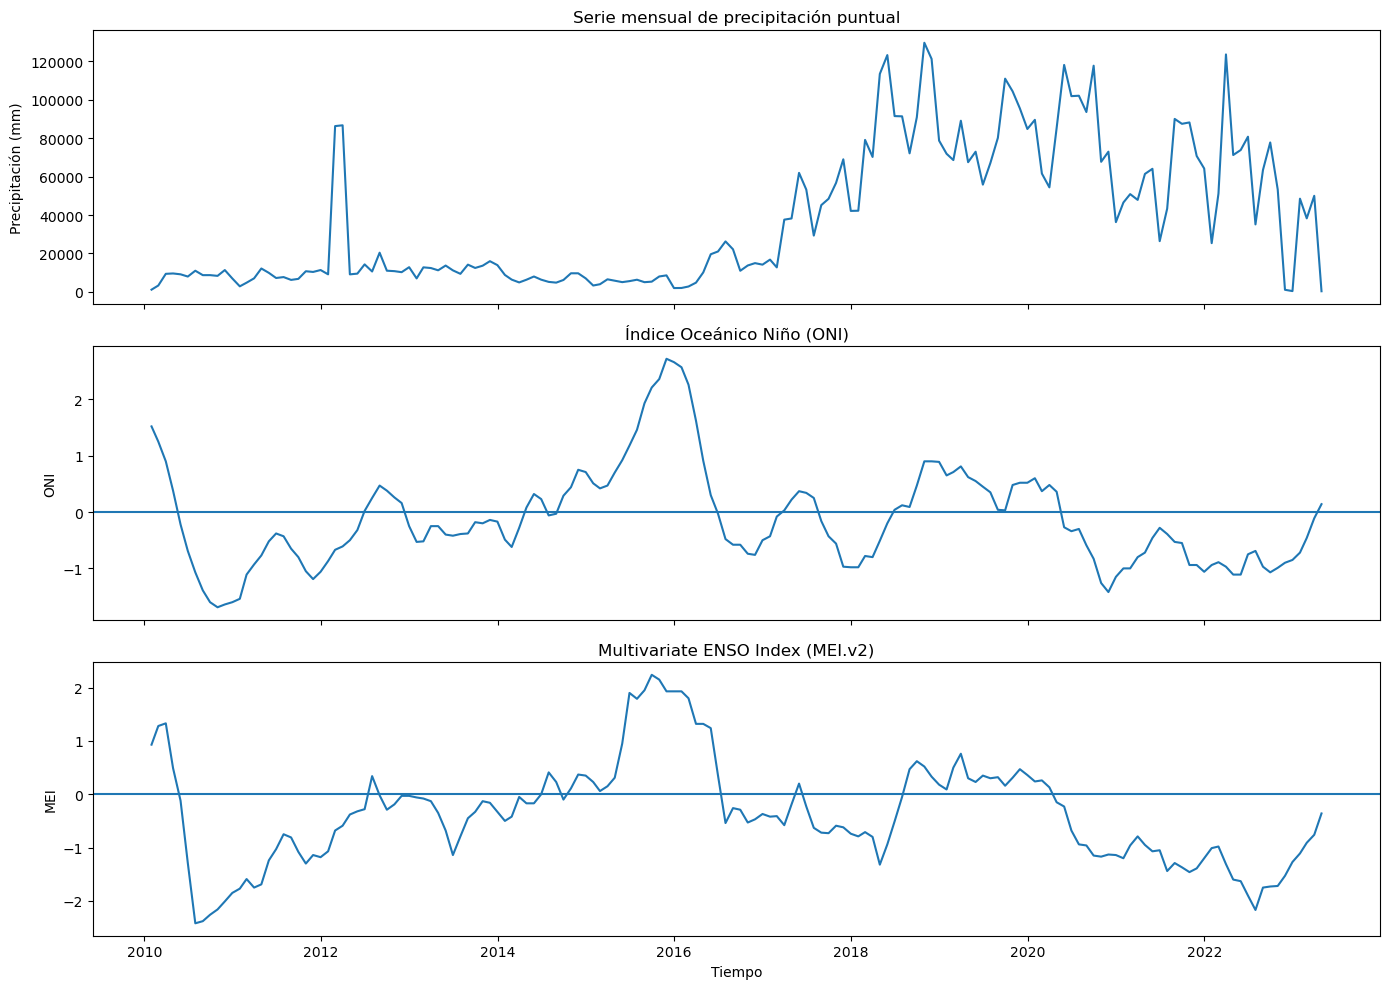

In [67]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# (i) Precipitación
axes[0].plot(df_2.index, df_2["Precip"])
axes[0].set_ylabel("Precipitación (mm)")
axes[0].set_title("Serie mensual de precipitación puntual")

# (ii) ONI
axes[1].plot(df_2.index, df_2["ONI"])
axes[1].axhline(0)
axes[1].set_ylabel("ONI")
axes[1].set_title("Índice Oceánico Niño (ONI)")

# (iii) MEI
axes[2].plot(df_2.index, df_2["MEI"])
axes[2].axhline(0)
axes[2].set_ylabel("MEI")
axes[2].set_title("Multivariate ENSO Index (MEI.v2)")

plt.xlabel("Tiempo")
plt.tight_layout()
plt.show()

In [76]:
def plot_enso_index(ax, time, values, ylabel, title):
    values = values.astype(float)

    # Máscaras
    pos = values > 0
    neg = values < 0

    # Barras positivas (El Niño)
    ax.bar(time[pos], values[pos],
           color='red',
           width=25)

    # Barras negativas (La Niña)
    ax.bar(time[neg], values[neg],
           color='steelblue',
           width=25)

    # Línea cero
    ax.axhline(0, color='black', linewidth=1)

    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

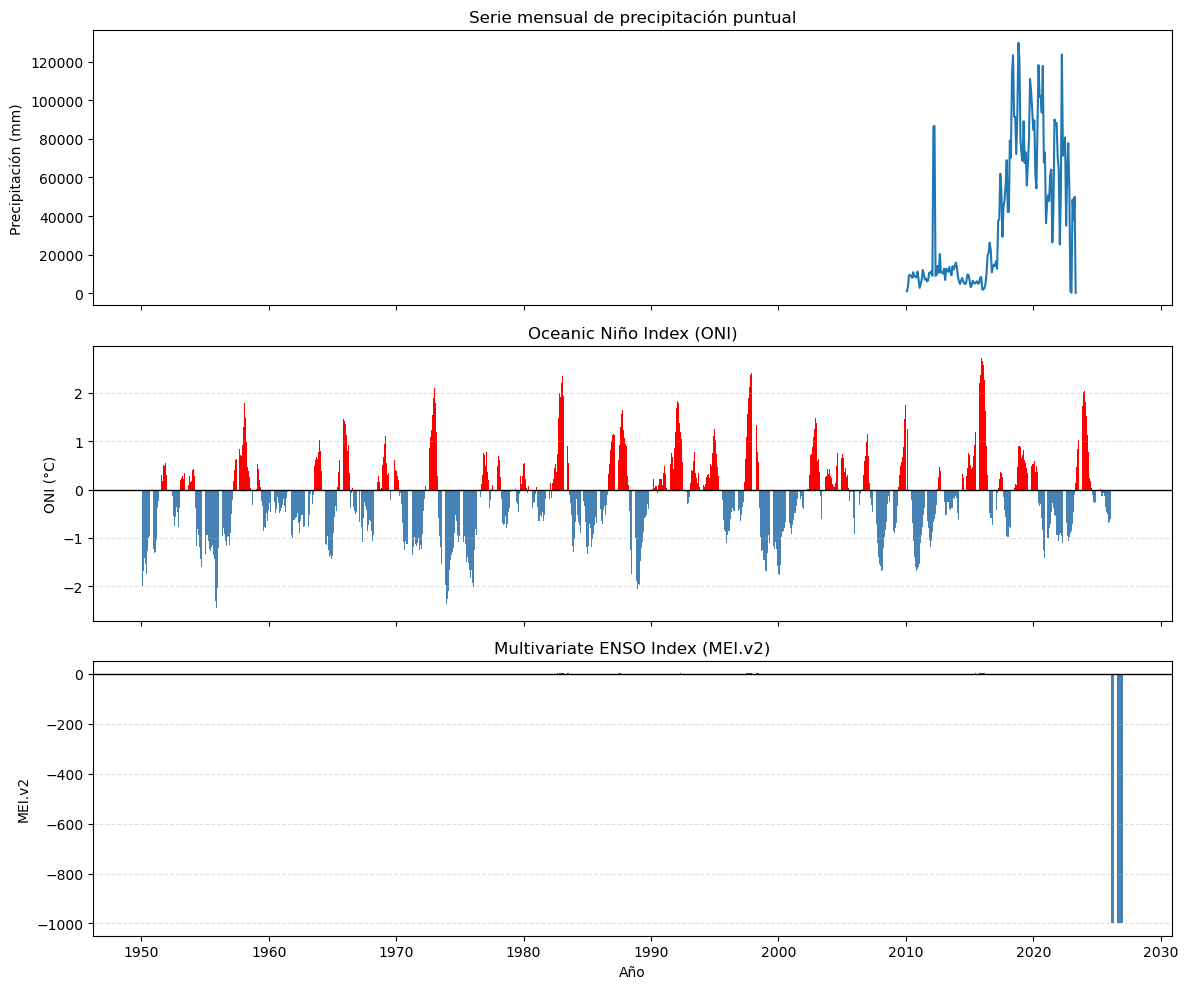

In [77]:
fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(12, 10),
    sharex=True
)

# (i) Precipitación
axes[0].plot(df_2.index, df_2["Precip"])
axes[0].set_ylabel("Precipitación (mm)")
axes[0].set_title("Serie mensual de precipitación puntual")

# (ii) ONI
plot_enso_index(
    ax=axes[1],
    time=oni.index,
    values=oni.values,
    ylabel="ONI (°C)",
    title="Oceanic Niño Index (ONI)"
)

# (iii) MEI
plot_enso_index(
    ax=axes[2],
    time=mei.index,
    values=mei.values,
    ylabel="MEI.v2",
    title="Multivariate ENSO Index (MEI.v2)"
)

axes[2].set_xlabel("Año")

plt.tight_layout()
plt.show()

# PUNTO 3

In [78]:
# Leer archivo
df_q = pd.read_csv("35107030.csv")

# Convertir fecha
df_q["Fecha"] = pd.to_datetime(df_q["Fecha"])

# Seleccionar columnas clave
q_daily = (
    df_q
    .loc[:, ["Fecha", "Valor"]]
    .rename(columns={"Valor": "Q_m3s"})
    .set_index("Fecha")
    .sort_index()
)

# Verificación rápida
q_daily.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 7958 entries, 2000-01-07 to 2021-12-31
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Q_m3s   7958 non-null   float64
dtypes: float64(1)
memory usage: 124.3 KB


In [81]:
q_monthly = q_daily.resample("ME").mean()
q_annual  = q_daily.resample("YE").mean()

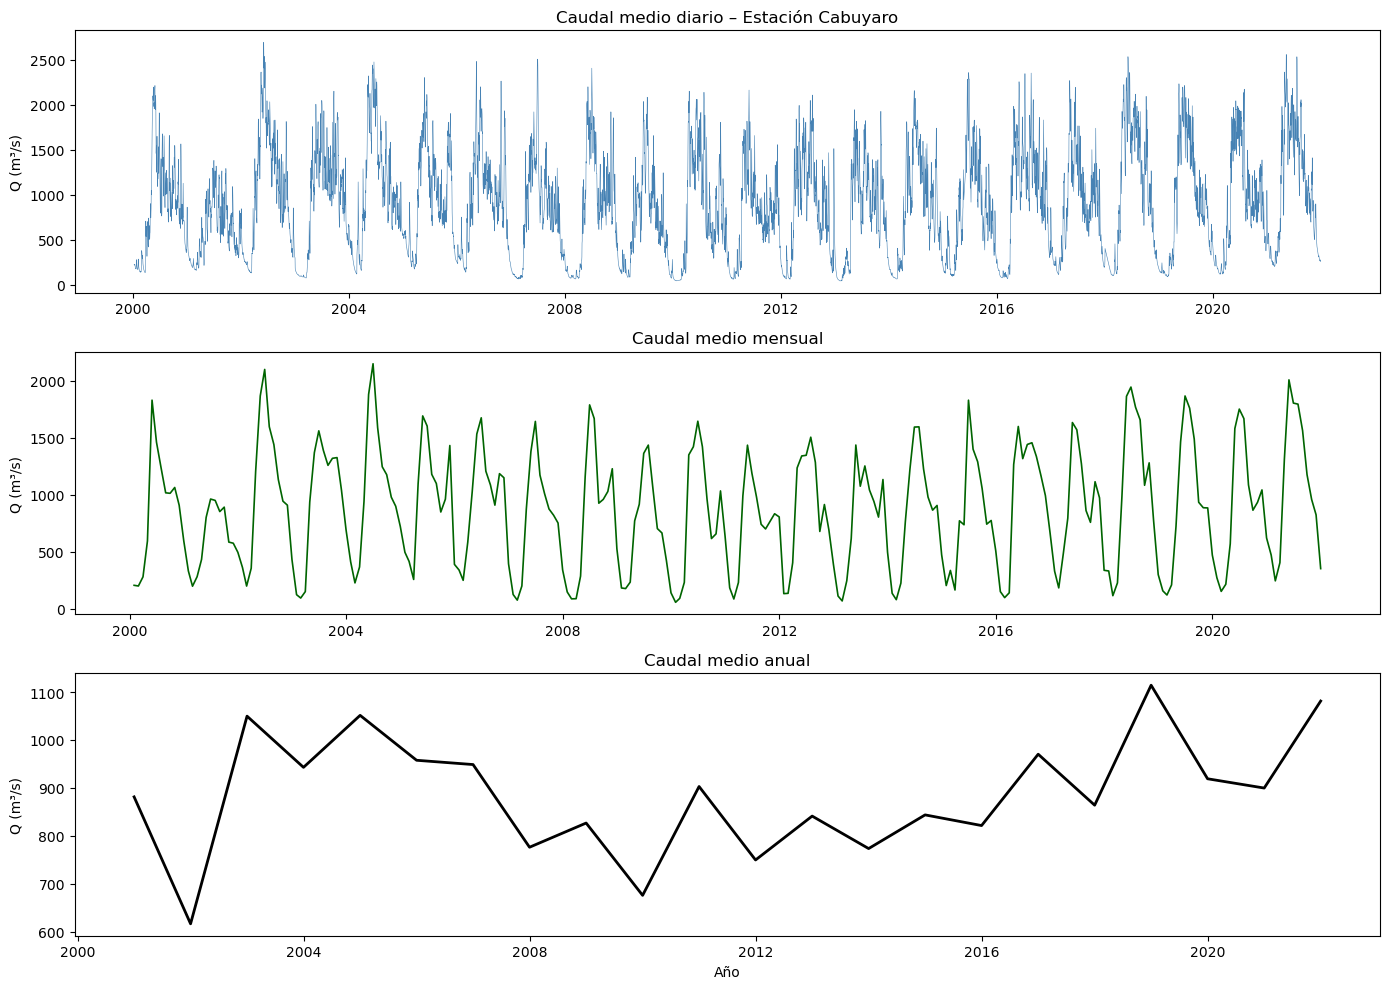

In [82]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)

# Diario
axes[0].plot(q_daily.index, q_daily["Q_m3s"], color="steelblue", linewidth=0.4)
axes[0].set_title("Caudal medio diario – Estación Cabuyaro")
axes[0].set_ylabel("Q (m³/s)")

# Mensual
axes[1].plot(q_monthly.index, q_monthly["Q_m3s"], color="darkgreen", linewidth=1.2)
axes[1].set_title("Caudal medio mensual")
axes[1].set_ylabel("Q (m³/s)")

# Anual
axes[2].plot(q_annual.index, q_annual["Q_m3s"], color="black", linewidth=2)
axes[2].set_title("Caudal medio anual")
axes[2].set_ylabel("Q (m³/s)")
axes[2].set_xlabel("Año")

plt.tight_layout()
plt.show()

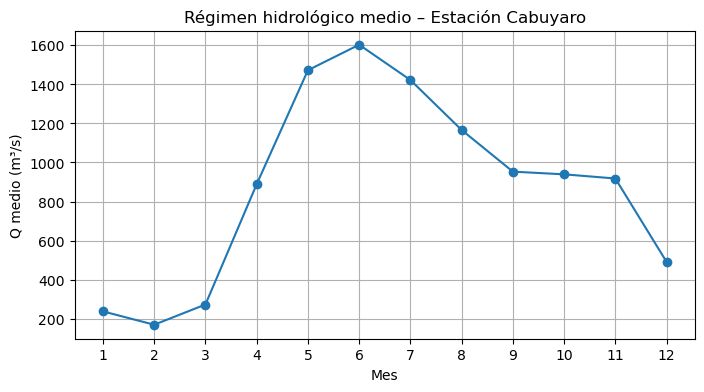

In [83]:
q_clim = q_daily.groupby(q_daily.index.month).mean()

plt.figure(figsize=(8,4))
plt.plot(q_clim.index, q_clim["Q_m3s"], marker="o")
plt.xticks(range(1,13))
plt.xlabel("Mes")
plt.ylabel("Q medio (m³/s)")
plt.title("Régimen hidrológico medio – Estación Cabuyaro")
plt.grid(True)
plt.show()

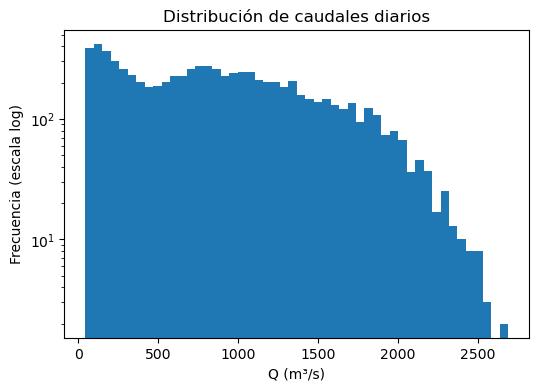

In [84]:
plt.figure(figsize=(6,4))
plt.hist(q_daily["Q_m3s"], bins=50, log=True)
plt.xlabel("Q (m³/s)")
plt.ylabel("Frecuencia (escala log)")
plt.title("Distribución de caudales diarios")
plt.show()